<a href="https://colab.research.google.com/github/ThamaraCrispim/Teste_Analytics_ThamaraBezerra-/blob/main/Teste_Analytics_ThamaraBezerra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Parte 1: Programação em Python**


1. Contexto do Problema

Uma empresa do setor de materiais de construção deseja compreender melhor o desempenho de suas vendas ao longo de 2023, com o objetivo de apoiar decisões comerciais e estratégicas.

Para realizar essa análise, foi utilizado um conjunto de dados simulado, contendo informações sobre data da venda, produto, categoria, quantidade e preço. Esses dados permitem observar o comportamento das vendas ao longo do tempo, identificar quais produtos geram maior faturamento e entender possíveis padrões relevantes para o planejamento do negócio.



A partir desse cenário, surge a seguinte pergunta central:

**Quais produtos mais contribuem para o faturamento da empresa e como as vendas se comportam ao longo do ano?**

In [1]:
#Bibliotecas
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt

**2. Simulação dos Dados**


In [2]:
# 2.1 Definição da semente aleatória

# A seed fixa o ponto inicial do gerador de números aleatórios.
# Isso garante que toda vez que o código for executado,
# os mesmos dados simulados sejam gerados (reprodutibilidade).

np.random.seed(42)   # seed do numpy
random.seed(42)      # seed do random (para garantir também)

In [3]:
# 2.2 Definição dos produtos e categorias

# Cada produto possui uma categoria e uma faixa de preço (mínimo e máximo)
# que será usada para sortear o valor unitário.

produtos = {
    "Cimento CP-II": {"categoria": "Estrutural", "preco_min": 30, "preco_max": 45},
    "Tijolo Cerâmico": {"categoria": "Estrutural", "preco_min": 500, "preco_max": 800},
    "Areia Ensacada": {"categoria": "Estrutural", "preco_min": 80, "preco_max": 150},
    "Tinta Acrílica": {"categoria": "Acabamento", "preco_min": 120, "preco_max": 250},
    "Piso Cerâmico": {"categoria": "Acabamento", "preco_min": 60, "preco_max": 120},
    "Rejunte": {"categoria": "Acabamento", "preco_min": 15, "preco_max": 40},
    "Furadeira": {"categoria": "Ferramentas", "preco_min": 250, "preco_max": 600},
    "Martelo": {"categoria": "Ferramentas", "preco_min": 25, "preco_max": 60},
    "Trena": {"categoria": "Ferramentas", "preco_min": 20, "preco_max": 50}
}

In [4]:
## 2.3 Geração dos registros de venda

num_registros = 200 #Número de registros 200

dados = [] #Uma lista vazia para armazebar os dados

In [5]:
for i in range(1, num_registros + 1):
    # Escolhe um produto aleatório da lista de produtos
    produto = random.choice(list(produtos.keys()))
    info = produtos[produto]   # pega as informações (categoria, preco_min, preco_max)

    # Gera uma data aleatória entre 01/01/2023 e 31/12/2023
    data = pd.to_datetime("2023-01-01") + pd.to_timedelta(
        random.randint(0, 364), unit="D"
    )

    # Gera a quantidade baseada na categoria (valores inteiros)
    if info["categoria"] == "Estrutural":
        quantidade = random.randint(5, 50)
    elif info["categoria"] == "Acabamento":
        quantidade = random.randint(3, 20)
    else:  # Ferramentas
        quantidade = random.randint(1, 5)

    # Gera o preço aleatório dentro da faixa do produto
    preco = round(random.uniform(info["preco_min"], info["preco_max"]), 2)

    # --- Inserir valores nulos intencionais ---
    # Com 5% de chance, a quantidade se torna nula
    if random.random() < 0.05:
        quantidade = np.nan
    # Com 5% de chance, o preço se torna nulo
    if random.random() < 0.05:
        preco = np.nan

    # Adiciona esse registro à lista 'dados'
    dados.append([
        i,               # ID (sequencial)
        data,            # Data
        produto,         # Produto
        info["categoria"], # Categoria
        quantidade,      # Quantidade (pode ser NaN)
        preco            # Preço (pode ser NaN)
    ])

In [6]:
# 2.4 Criação do DataFrame e salvamento dos dados brutos
df_raw = pd.DataFrame(dados, columns=[
    "ID", "Data", "Produto", "Categoria", "Quantidade", "Preço"
])

In [7]:
# Salva em um arquivo CSV (sem o índice)
df_raw.to_csv("data_raw.csv", index=False)

In [8]:
#Visualize as primeiras linhas para conferir:
df_raw.head()



,ID,Data,Produto,Categoria,Quantidade,Preço
0,1,2023-01-13,Tijolo Cerâmico,Estrutural,22.0,573.47
1,2,2023-02-14,Trena,Ferramentas,NaN,32.66
2,3,2023-11-05,Trena,Ferramentas,1.0,36.84
3,4,2023-04-23,Furadeira,Ferramentas,4.0,NaN
4,5,2023-12-24,Areia Ensacada,Estrutural,32.0,103.82


In [9]:
# 2.5 Informações básicas do dataset gerado
print("Dimensões do dataset:", df_raw.shape)
print("\nQuantidade de valores nulos por coluna:")
print(df_raw.isnull().sum())
print("\nTipos de dados:")
print(df_raw.dtypes)

Dimensões do dataset: (200, 6)

Quantidade de valores nulos por coluna:
ID            0
Data          0
Produto       0
Categoria     0
Quantidade    6
Preço         8
dtype: int64

Tipos de dados:
ID                     int64
Data          datetime64[ns]
Produto               object
Categoria             object
Quantidade           float64
Preço                float64
dtype: object


**Dicionário de Dados**

ID - Identificador único de cada transação de venda.

Data - Data em que a compra foi realizada.

Produto - Nome do produto adquirido na transação.

Categoria - Classificação do produto (ex.: Estrutural, Acabamento, Ferramentas).

Quantidade - Número de unidades adquiridas na compra.

Preço - Valor unitário do produto no momento da venda (R$).

Total vendas - Preço * Quantidade valores total de vendas

**3.Limpeza e Tratamento**

In [10]:
# 3.1 Carregar os dados simulados (com valores nulos)
df = pd.read_csv("data_raw.csv", parse_dates=["Data"])

In [11]:
# 3.2 Dimensões do dataset
df.shape

(200, 6)

In [12]:
# 3.3 Verificação de valores nulos (antes do tratamento)
df.isnull().sum()

,0
ID,0
Data,0
Produto,0
Categoria,0
Quantidade,6
Preço,8


In [13]:
# 3.4 Tratamento de valores nulos

# Estratégia adotada:
# - Para 'Quantidade': preencher com a mediana da categoria (produtos da mesma categoria tendem a ter volumes semelhantes)
# - Para 'Preço': preencher com a média do produto (o preço é uma característica intrínseca de cada produto)
# - Caso ainda restem nulos (ex.: produto sem nenhum preço válido), usar a média/mediana global.

# Preenchendo Quantidade com a mediana da categoria
df["Quantidade"] = df.groupby("Categoria")["Quantidade"].transform(
    lambda x: x.fillna(x.median())
)

# Preenchendo Preço com a média do produto
df["Preço"] = df.groupby("Produto")["Preço"].transform(
    lambda x: x.fillna(x.mean())
)

# Se ainda houver nulos (ex.: produto sem nenhum preço), usar a média global para Preço
df["Preço"] = df["Preço"].fillna(df["Preço"].mean())

# Para Quantidade, usar a mediana global (caso alguma categoria fique sem mediana válida)
df["Quantidade"] = df["Quantidade"].fillna(df["Quantidade"].median())


In [14]:
# 3.5 Verificação após tratamento
print("\nValores nulos DEPOIS do tratamento:")
print(df.isnull().sum())



Valores nulos DEPOIS do tratamento:
ID            0
Data          0
Produto       0
Categoria     0
Quantidade    0
Preço         0
dtype: int64


**Tratamento de valores nulos:**

Para preservar a integridade das informações de vendas e evitar a perda de registros importantes, optamos por preencher os valores ausentes nas colunas 'Quantidade' e 'Preço' em vez de removê-los. Essa decisão baseia-se no entendimento de que cada linha representa uma transação real de um cliente, e excluí-la comprometeria a análise de comportamento de compra e a precisão dos resultados.



In [15]:
# 3.6 Remoção de duplicatas (se houver)
df.duplicated().sum()


np.int64(0)

In [16]:
# 3.7 Criação da coluna Total_Vendas (Quantidade * Preço)
df["Total_Vendas"] = df["Quantidade"] * df["Preço"]

In [17]:
# Verificando o tipo dos dados
df.dtypes

,0
ID,int64
Data,datetime64[ns]
Produto,object
Categoria,object
Quantidade,float64
Preço,float64
Total_Vendas,float64


In [18]:
# 3.8 Ajuste de tipos de dados
# Converter Quantidade para inteiro (agora sem nulos)
df["Quantidade"] = df["Quantidade"].astype(int)

# Verificar os tipos após conversão
print("\nTipos de dados após ajustes:")
print(df.dtypes)


Tipos de dados após ajustes:
ID                       int64
Data            datetime64[ns]
Produto                 object
Categoria               object
Quantidade               int64
Preço                  float64
Total_Vendas           float64
dtype: object


In [19]:
# 3.9 Salvar dataset limpo
df.to_csv("data_clean.csv", index=False)
print("\nArquivo 'data_clean.csv' salvo com sucesso.")


Arquivo 'data_clean.csv' salvo com sucesso.


In [20]:
# 3.10 Visualização das primeiras e últimas linhas
print("\nPrimeiras 5 linhas:")
df.head()



Primeiras 5 linhas:


,ID,Data,Produto,Categoria,Quantidade,Preço,Total_Vendas
0,1,2023-01-13,Tijolo Cerâmico,Estrutural,22,573.470000,12616.340000
1,2,2023-02-14,Trena,Ferramentas,3,32.660000,97.980000
2,3,2023-11-05,Trena,Ferramentas,1,36.840000,36.840000
3,4,2023-04-23,Furadeira,Ferramentas,4,421.574074,1686.296296
4,5,2023-12-24,Areia Ensacada,Estrutural,32,103.820000,3322.240000


In [21]:
print("\nÚltimas 5 linhas:")
df.tail()


Últimas 5 linhas:


,ID,Data,Produto,Categoria,Quantidade,Preço,Total_Vendas
195,196,2023-06-14,Tijolo Cerâmico,Estrutural,43,544.50,23413.50
196,197,2023-12-31,Trena,Ferramentas,3,31.43,94.29
197,198,2023-11-06,Trena,Ferramentas,4,22.98,91.92
198,199,2023-04-21,Trena,Ferramentas,4,33.55,134.20
199,200,2023-07-24,Martelo,Ferramentas,4,50.54,202.16


**Análise Inicial**

O DataFrame analisado contém 200 registros de vendas realizadas ao longo de 2023, representando todas as transações efetuadas pela loja no período. Cada registro inclui informações como data da venda, produto, categoria, quantidade e valor, permitindo avaliar o desempenho comercial da empresa, identificar padrões de consumo e analisar oportunidades de crescimento e otimização do mix de produtos.

**4. Análise Descritiva**

In [22]:
# 4.1 Função para gerar metadados
def generate_metadata(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Gera uma tabela de metadados contendo informações estruturais do DataFrame.
    """
    metadata = pd.DataFrame({
        "nome_variavel": dataframe.columns,
        "tipo_dado": dataframe.dtypes.astype(str),
        "qt_nulos": dataframe.isnull().sum(),
        "percent_nulos": round(
            (dataframe.isnull().sum() / len(dataframe)) * 100, 2
        ),
        "cardinalidade": dataframe.nunique(dropna=True)
    })
    return metadata

# Aplicar a função ao nosso DataFrame limpo
metadata_df = generate_metadata(df)
print("=== Metadados do Dataset (visão geral) ===\n")
print(metadata_df)

=== Metadados do Dataset (visão geral) ===

             nome_variavel       tipo_dado  qt_nulos  percent_nulos  \
ID                      ID           int64         0            0.0   
Data                  Data  datetime64[ns]         0            0.0   
Produto            Produto          object         0            0.0   
Categoria        Categoria          object         0            0.0   
Quantidade      Quantidade           int64         0            0.0   
Preço                Preço         float64         0            0.0   
Total_Vendas  Total_Vendas         float64         0            0.0   

              cardinalidade  
ID                      200  
Data                    159  
Produto                   9  
Categoria                 3  
Quantidade               41  
Preço                   196  
Total_Vendas            200  


**Análise Inicial**

- A base reúne 200 vendas realizadas ao longo de 2023, todas válidas e sem inconsistências estruturais, o que garante segurança para avançar nas análises de desempenho.

- A empresa opera com 3 categorias e 9 produtos, indicando um portfólio relativamente enxuto. Esse cenário facilita a gestão comercial, mas também pode gerar dependência de poucos itens para sustentar o faturamento.

- A variação nas quantidades vendidas mostra que existem compras de diferentes volumes, com registros de mais de uma venda no mesmo dia. Isso sugere movimentação recorrente e abre espaço para estratégias que incentivem pedidos maiores, aumentando o valor médio por transação.

- As vendas estão distribuídas ao longo de 159 dias distintos, indicando atividade comercial ao longo de todo o ano. Essa distribuição permite analisar períodos de maior desempenho e direcionar ações comerciais de forma mais estratégica.

- O fato de praticamente cada venda possuir um valor final distinto demonstra diversidade nos pedidos realizados, seja por diferença de produtos ou quantidades. Isso impacta diretamente a geração de receita e reforça a importância de identificar quais itens estão puxando o faturamento.

In [23]:
# 4.2 Estatísticas descritivas das colunas numéricas
print("\n=== Estatísticas descritivas (valores numéricos) ===\n")
display(df[["Quantidade", "Preço", "Total_Vendas"]].describe().round(2))


=== Estatísticas descritivas (valores numéricos) ===



,Quantidade,Preço,Total_Vendas
count,200.00,200.00,200.00
mean,11.78,186.42,2675.42
std,10.89,210.96,5442.56
min,1.00,15.35,23.46
25%,3.00,38.38,209.05
50%,8.00,87.08,785.26
75%,18.00,254.90,1844.89
max,48.00,777.17,28470.24


Insight – Estatísticas Descritivas

- O valor médio por venda é de 2.675 reais, enquanto a mediana é de 785 reais. Essa diferença indica que existem poucas vendas de alto valor que elevam a média geral, sugerindo possível concentração do faturamento em pedidos maiores.

- O valor máximo registrado (28.470 reais) reforça a presença de transações significativamente acima do padrão, o que pode representar compras em grande volume ou pedidos de maior porte.

- A quantidade vendida varia de 1 a 48 unidades, com mediana de 8 unidades por venda. Isso indica que a maioria das compras não é extremamente volumosa, mas há pedidos maiores que impactam diretamente a receita.

- O desvio padrão elevado no valor total das vendas demonstra alta variação entre os pedidos, sugerindo que o desempenho financeiro pode oscilar dependendo da presença ou ausência dessas vendas de maior porte.

In [24]:
# 4.3 Faturamento total e médio por categoria
print("\n=== Faturamento por Categoria ===\n")
faturamento_categoria = df.groupby("Categoria")["Total_Vendas"].agg(["sum", "mean", "count"]).round(2)
faturamento_categoria.columns = ["Faturamento Total (R$)", "Ticket Médio (R$)", "Nº de Vendas"]
faturamento_categoria = faturamento_categoria.sort_values("Faturamento Total (R$)", ascending=False)
display(faturamento_categoria)


=== Faturamento por Categoria ===



,Faturamento Total (R$),Ticket Médio (R$),Nº de Vendas
Categoria,,,
Estrutural,418630.85,7344.40,57
Acabamento,75855.33,1185.24,64
Ferramentas,40597.63,513.89,79


Insight – Faturamento por Categoria

- A categoria Estrutural concentra o maior faturamento, com 418.630 reais, mesmo tendo apenas 57 vendas. Além disso, apresenta o maior ticket médio (7.344 reais), indicando que essa categoria é responsável pelas vendas de maior valor e exerce forte impacto na receita total.

- A categoria Acabamento gerou 75.855 reais em 64 vendas, com ticket médio de 1.185 reais. Isso mostra um desempenho intermediário, com vendas mais frequentes que Estrutural, porém com menor valor por transação.

- Já Ferramentas possui o maior número de vendas (79), mas o menor faturamento total (40.597 reais) e o menor ticket médio (513 reais). Isso indica que, apesar do alto volume, essa categoria contribui menos para a receita.

In [25]:
# 4.4 Top 5 produtos por faturamento
print("\n=== Top 5 Produtos que Mais Faturaram ===\n")
top5_produtos = df.groupby("Produto")["Total_Vendas"].sum().sort_values(ascending=False).head(5).round(2)
print(top5_produtos.to_string())


=== Top 5 Produtos que Mais Faturaram ===

Produto
Tijolo Cerâmico    369700.75
Tinta Acrílica      42750.38
Furadeira           34680.52
Areia Ensacada      31575.13
Piso Cerâmico       27136.88


Insight – Top 5 Produtos com Maior Faturamento

A análise dos cinco produtos que mais faturaram revela uma forte concentração de receita em um único item. O Tijolo Cerâmico apresentou faturamento de 369.700 reais, valor significativamente superior aos demais produtos do ranking.

O segundo colocado, Tinta Acrílica, registrou 42.750 reais, seguido por Furadeira (34.680 reais), Areia Ensacada (31.575 reais) e Piso Cerâmico (27.136 reais). Observa-se que há uma grande diferença entre o primeiro colocado e os demais, indicando alta dependência do faturamento em relação ao Tijolo Cerâmico.

In [26]:
# 4.5 Produtos com maior quantidade vendida
print("\n=== Produtos com Maior Volume de Vendas (Quantidade Total) ===\n")
top5_qtd = df.groupby("Produto")["Quantidade"].sum().sort_values(ascending=False).head(5)
print(top5_qtd.to_string())


=== Produtos com Maior Volume de Vendas (Quantidade Total) ===

Produto
Tijolo Cerâmico    600
Cimento CP-II      467
Piso Cerâmico      302
Areia Ensacada     298
Tinta Acrílica     240


Insight – Produtos com Maior Volume de Vendas

A análise do volume total vendido revela quais produtos possuem maior giro dentro da operação. O Tijolo Cerâmico lidera com 600 unidades vendidas, seguido por Cimento CP-II (467 unidades), Piso Cerâmico (302 unidades), Areia Ensacada (298 unidades) e Tinta Acrílica (240 unidades).

O destaque novamente é o Tijolo Cerâmico, que além de liderar em faturamento, também apresenta o maior volume de vendas. Isso indica que seu desempenho não é resultado apenas de preço elevado, mas também de alta demanda e forte giro comercial. Trata-se, portanto, de um produto estratégico para a sustentação da receita da empresa.

In [27]:
# 4.6 Salvando os dados com a coluna de mês (já existente) para análises futuras
# A coluna 'Mes' já foi criada na etapa anterior, mas vamos garantir que está presente
if "Mes" not in df.columns:
    df["Mes"] = df["Data"].dt.strftime("%Y-%m")

**5. Análise Exploratória**

In [28]:
# 5.1 Preparação dos dados mensais

# Garantir tipos e criar coluna de mês
df['Data'] = pd.to_datetime(df['Data'], errors='coerce')
df = df.dropna(subset=['Data'])
df['Mes'] = df['Data'].dt.strftime('%Y-%m')

# Garantir coluna de Total_Vendas
if 'Total_Vendas' not in df.columns:
    df['Total_Vendas'] = df['Quantidade'] * df['Preço']

# Agrupar faturamento mensal
faturamento_mensal = df.groupby('Mes')['Total_Vendas'].sum().sort_index()

# Criar listas ordenadas para os gráficos
meses_ordenados = faturamento_mensal.index.tolist()
valores_mensais = faturamento_mensal.values

# Criar um DataFrame para exibição em tabela
tabela_mensal = pd.DataFrame({
    'Mês': meses_ordenados,
    'Faturamento (R$)': valores_mensais
})
tabela_mensal['Faturamento (R$)'] = tabela_mensal['Faturamento (R$)'].round(2)
display(tabela_mensal)

,Mês,Faturamento (R$)
0,2023-01,47774.85
1,2023-02,71382.65
2,2023-03,30362.90
3,2023-04,30901.85
4,2023-05,73076.81
5,2023-06,43486.52
6,2023-07,7104.47
7,2023-08,42350.86
8,2023-09,49527.87
9,2023-10,24911.14


Insight – Evolução Mensal do Faturamento

Faturamento ao longo de 2023 revela variações significativas entre os meses, indicando possível sazonalidade ou oscilações operacionais.

Os meses com maior faturamento foram:

- Maio (73.076 reais)

- Dezembro (72.592 reais)

- Fevereiro (71.382 reais)

Esses períodos representam os picos de receita do ano, sugerindo momentos de maior demanda ou campanhas comerciais mais eficientes.

Por outro lado, julho apresentou faturamento de apenas 7.104 reais, valor extremamente inferior aos demais meses.

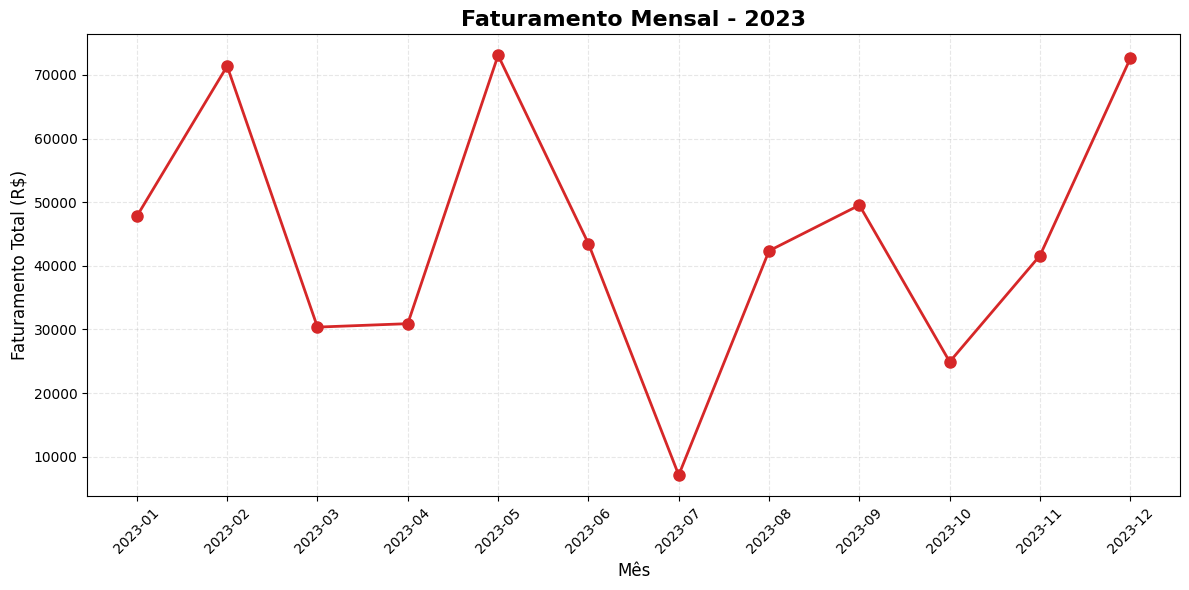

In [29]:
# 5.2 Gráfico de linha: tendência de vendas ao longo do ano
plt.figure(figsize=(12, 6))
plt.plot(meses_ordenados, valores_mensais, marker='o', color='#d62728', linewidth=2, markersize=8)

plt.title('Faturamento Mensal - 2023', fontsize=16, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Faturamento Total (R$)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Insight – Evolução Mensal do Faturamento

O gráfico acima mostra como as vendas se comportaram mês a mês em 2023. E aqui está o que esses números significam para o negócio:

- Os meses que mais puxaram o faturamento foram Fevereiro, Maio e Dezembro.

- Fevereiro provavelmente reflete o início de obras após o verão, quando as construções voltam com força.

- Maio é um mês clássico de aquecimento no setor – reformas e novos projetos começam a sair do papel.

- Dezembro, como esperado, é o mês de fechar obras e entregar chaves, o que gera uma corrida por materiais.

- Julho foi o mês mais fraco, com faturamento muito abaixo da média.

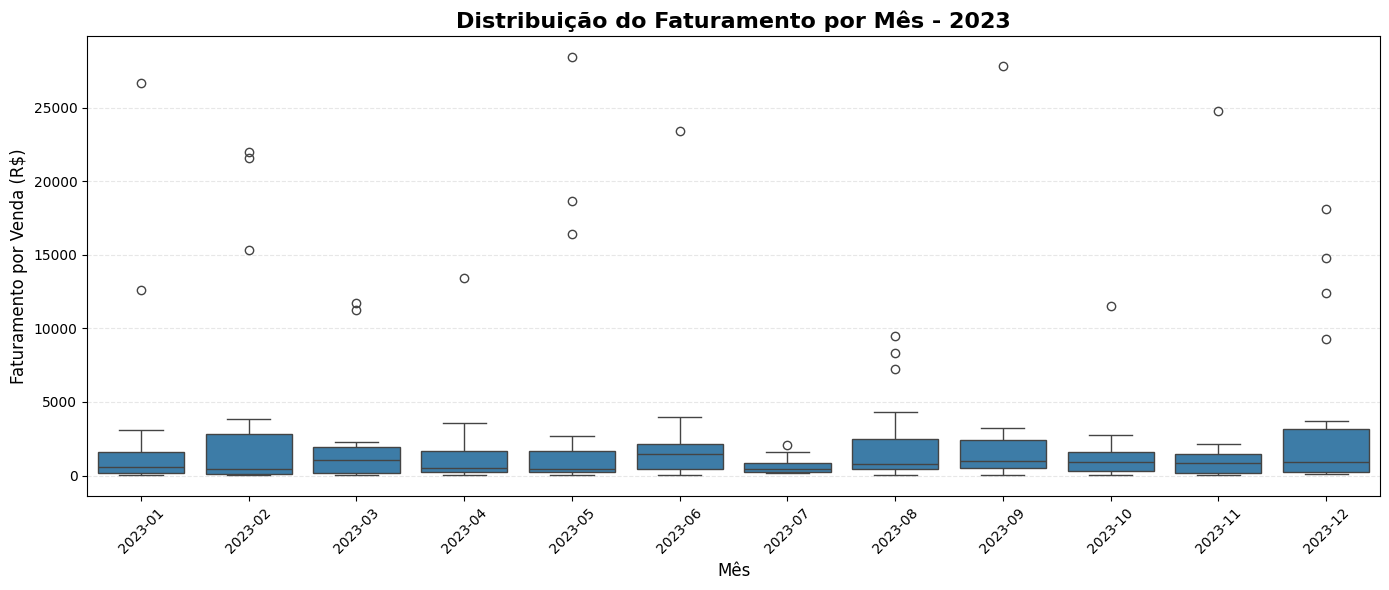

In [30]:
# 5.3 Boxplot: distribuição do faturamento por mês
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Mes', y='Total_Vendas', color='#2c7fb8', order=meses_ordenados)

plt.title('Distribuição do Faturamento por Mês - 2023', fontsize=16, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Faturamento por Venda (R$)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Análise do gráfico

O boxplot mostra a distribuição do faturamento das vendas em cada mês de 2023. Observa-se que a maioria das vendas está concentrada em valores mais baixos, enquanto alguns meses apresentam pontos muito acima da distribuição principal.

Meses como fevereiro, maio e setembro apresentam maior variação e alguns valores mais altos, indicando a ocorrência de vendas maiores nesses períodos. Já meses como julho apresentam valores mais concentrados, sugerindo menor variação no faturamento das vendas.

Isso indica que, apesar de haver um padrão relativamente consistente de vendas, alguns meses possuem transações de maior valor que impactam a distribuição do faturamento!

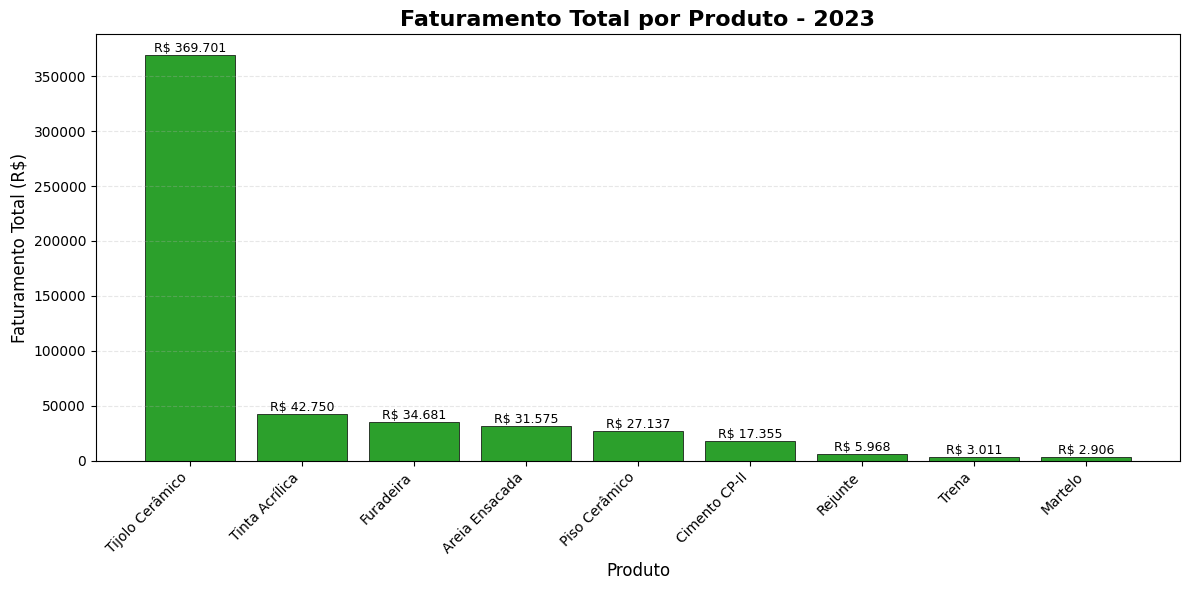

In [31]:
# 5.4 Gráfico de barras: faturamento total por produto
faturamento_produto = df.groupby('Produto')['Total_Vendas'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(faturamento_produto.index, faturamento_produto.values, color='#2ca02c', edgecolor='black', linewidth=0.5)

plt.title('Faturamento Total por Produto - 2023', fontsize=16, fontweight='bold')
plt.xlabel('Produto', fontsize=12)
plt.ylabel('Faturamento Total (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Adicionar valores sobre as barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'R$ {height:,.0f}'.replace(',', '.'),
             ha='center', va='bottom', fontsize=9, rotation=0)

plt.tight_layout()
plt.show()

Análise do gráfico

O gráfico apresenta o faturamento total por produto em 2023. É possível observar que o Tijolo Cerâmico se destaca significativamente, gerando um faturamento muito superior aos demais produtos.

Os outros itens, como Tinta Acrílica, Furadeira e Areia Ensacada, apresentam valores consideravelmente menores, mas ainda relevantes dentro do conjunto de vendas. Já produtos como Rejunte, Trena e Martelo possuem participação bem menor no faturamento total.

**6. Insights de Negócio**


A análise dos dados de vendas de 2023 mostra que alguns produtos têm impacto muito maior no faturamento do que outros. O Tijolo Cerâmico se destaca significativamente, indicando que ele é um dos principais responsáveis pela geração de receita. Isso sugere que esse produto possui alta demanda e desempenha um papel estratégico nas vendas.

Além disso, ao observar a distribuição das vendas ao longo dos meses, percebe-se que a maioria das transações possui valores menores, mas existem algumas vendas de valor mais alto que influenciam o faturamento em determinados períodos. Isso indica que parte da receita pode estar concentrada em vendas específicas ou em produtos de maior valor.

Pensando no negócio, esses resultados sugerem oportunidades como ampliar o portfólio de produtos relacionados ao item mais vendido, como outros tipos de tijolos ou materiais complementares. Também seria interessante investigar quais fatores impulsionam as vendas de maior valor para potencializar essas oportunidades e melhorar o desempenho das vendas ao longo do tempo


